# Inital Exploratory Data Analysis v2

**NUS Industry 4.0 Capstone — 3D Bin Packing / Cartonization**

This notebook reruns the initial EDA using `data/raw/data_samples_v2.json`. It focuses on order complexity, carton selection, packing constraints, utilization and reference-service latency. Each chart is followed by a short interpretation so the results are readable without needing to inspect the code.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)

candidates = [Path("../data/raw/data_samples_v2.json"), Path("data/raw/data_samples_v2.json"), Path("data_samples_v2.json")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place data_samples_v2.json in data/raw/ or next to this notebook.")
with DATA_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)
print(f"Loaded {len(raw):,} orders from {DATA_PATH}")

Loaded 2,000 orders from ../data/raw/data_samples_v2.json


## 1. What does the v2 data look like?

The source remains a nested request/response JSON structure. The first table flattens a few orders so that each row represents an input item line together with the reference carton selection and response information.

In [2]:
rows=[]
for rec in raw[:5]:
    inp, out = rec["input"], rec["output"]
    packed = out["Data"]["BinsPacked"]
    selected = ", ".join(b["Code"] for b in packed)
    used = ", ".join(f'{b["UsedSpace"]:.1f}%' for b in packed)
    for item in inp["Items"]["ItemsList"]:
        rows.append({"OrderId": inp["OrderId"], "ItemCode": item["Code"], "Length_mm": item["Length"], "Width_mm": item["Width"], "Height_mm": item["Height"], "Weight_kg": item["Weight"], "UOM": item["UOM"], "VerticalRotation": item["VerticalRotation"], "Quantity": item["Quantity"], "SelectedBox": selected, "UsedSpace": used, "Status": out["StatusMessage"], "Latency_ms": rec["latency_ms"]})
display(pd.DataFrame(rows))

,OrderId,ItemCode,Length_mm,Width_mm,Height_mm,Weight_kg,UOM,VerticalRotation,Quantity,SelectedBox,UsedSpace,Status,Latency_ms
0,1,63,140,80,116.00,0.28,EA,1,1,Box4,29.0%,Success,410.02
1,1,70,160,80,120.00,0.19,EA,1,1,Box4,29.0%,Success,410.02
2,1,66,55,55,110.00,0.13,EA,1,1,Box4,29.0%,Success,410.02
3,1,75,70,65,115.00,0.16,EA,1,1,Box4,29.0%,Success,410.02
4,2,30,245,40,125.00,0.20,BOX,1,2,Box5,54.5%,Success,194.64
5,2,132,80,80,210.00,0.65,EA,0,1,Box5,54.5%,Success,194.64
6,2,131,60,60,145.00,0.28,EA,1,2,Box5,54.5%,Success,194.64
7,2,9,255,40,192.00,1.25,SET,1,1,Box5,54.5%,Success,194.64
8,2,63,140,80,116.00,0.28,EA,1,1,Box5,54.5%,Success,194.64
9,2,64,55,55,115.00,0.12,EA,1,1,Box5,54.5%,Success,194.64


## 2. Carton catalogue and packing rules

In [3]:
bins_cfg = pd.DataFrame(raw[0]["input"]["Bins"]["BinsList"])[["Code","Length","Width","Height","MaxWeight"]]
params = raw[0]["input"]["Bins"]["Parameters"]
display(bins_cfg)
display(pd.Series({"BinMaxFillCheckMinItemQty": params["BinMaxFillCheckMinItemQty"], "BinMaxFillPct": params["BinMaxFillPct"], "Buffer_Length_mm": params["BinBuffer"]["Length"], "Buffer_Width_mm": params["BinBuffer"]["Width"], "Buffer_Height_mm": params["BinBuffer"]["Height"]}, name="Value").to_frame())

,Code,Length,Width,Height,MaxWeight
0,Box2,270.00,170.00,115.00,20
1,Box4,340.00,260.00,150.00,20
2,Box5,340.00,260.00,235.00,20
3,Box6,340.00,260.00,280.00,20
4,Box8,290.00,180.00,280.00,20
5,Box9,440.00,345.00,280.00,20


,Value
BinMaxFillCheckMinItemQty,6
BinMaxFillPct,70
Buffer_Length_mm,0
Buffer_Width_mm,0
Buffer_Height_mm,6


**Insight.** v2 contains six candidate cartons. `Box3` is no longer present, while `Box2` is now 270 mm long. The packing rules remain a six-item threshold, 70% maximum fill above that threshold and a 6 mm height buffer. This is why the solver should consume the carton catalogue from input rather than hard-code carton definitions.

In [4]:
order_rows=[]; item_rows=[]; packed_rows=[]
for rec in raw:
    inp, out = rec["input"], rec["output"]
    items = inp["Items"]["ItemsList"]
    bins = out["Data"]["BinsPacked"]
    order_rows.append({"order_id": inp["OrderId"], "success": out["StatusCode"]==0, "item_lines": len(items), "item_qty": sum(i["Quantity"] for i in items), "total_weight_kg": sum(i["Weight"]*i["Quantity"] for i in items), "bins_used": len(bins), "upright_only": any(i["VerticalRotation"]==0 for i in items), "latency_ms": rec["latency_ms"], "unpacked_count": sum(i.get("Quantity",1) for i in out["Data"].get("NotPackedItems",[]))})
    for i in items: item_rows.append({**i, "OrderId": inp["OrderId"]})
    for b in bins: packed_rows.append({"OrderId": inp["OrderId"], "box": b["Code"], "used_space": b["UsedSpace"]})
orders_df=pd.DataFrame(order_rows); items_df=pd.DataFrame(item_rows); packed_df=pd.DataFrame(packed_rows)

## 3. Dataset summary

In [5]:
kpis=pd.Series({"Orders":len(orders_df),"Successful orders":int(orders_df.success.sum()),"Orders with unpacked items":int((orders_df.unpacked_count>0).sum()),"Unique item codes":items_df.Code.nunique(),"Physical item quantity":int(items_df.Quantity.sum()),"Average physical items/order":orders_df.item_qty.mean(),"Median physical items/order":orders_df.item_qty.median(),"Orders with upright-only items":int(orders_df.upright_only.sum()),"Average boxes/order":orders_df.bins_used.mean(),"Median latency (ms)":orders_df.latency_ms.median()})
display(kpis.to_frame("Value"))

,Value
Orders,"2,000.00"
Successful orders,"2,000.00"
Orders with unpacked items,0.00
Unique item codes,150.00
Physical item quantity,"15,103.00"
Average physical items/order,7.55
Median physical items/order,6.00
Orders with upright-only items,727.00
Average boxes/order,1.07
Median latency (ms),187.25


**Insight.** All 2,000 reference orders succeed and none contain unpacked items. The sample contains 15,103 physical items across 150 item codes. A typical order is small: the median is 6 physical items and the average is 7.55. About 36% of orders contain at least one upright-only item, so rotation constraints are material rather than edge cases.

## 4. Order complexity

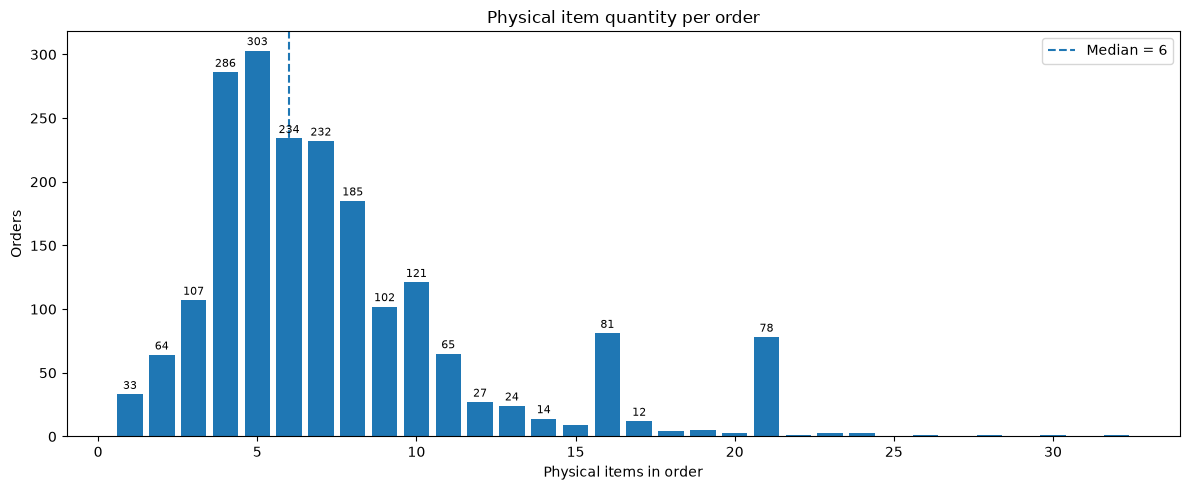

In [6]:
s=orders_df.item_qty.value_counts().sort_index()
fig,ax=plt.subplots(figsize=(12,5)); bars=ax.bar(s.index,s.values)
ax.set(title="Physical item quantity per order", xlabel="Physical items in order", ylabel="Orders")
ax.axvline(orders_df.item_qty.median(), linestyle="--", linewidth=1.5, label=f'Median = {orders_df.item_qty.median():.0f}')
ax.legend()
ax.bar_label(bars, labels=[str(v) if v>=10 else "" for v in s.values], padding=2, fontsize=8)
plt.tight_layout(); plt.show()

**Insight.** The distribution is concentrated around moderate-size orders: **73.2% of orders contain 4–10 physical items**, and the **median is 6**. There are visible secondary spikes at **16 items (81 orders)** and **21 items (78 orders)**. Inspection of those orders shows that these spikes are driven by recurring high-quantity order patterns, particularly repeated item codes such as `343` and `313`, rather than simply being explained by unusually small items. The long right tail means the solver still needs to handle occasional orders above 20 items efficiently.

## 5. Primary objective: number of boxes used

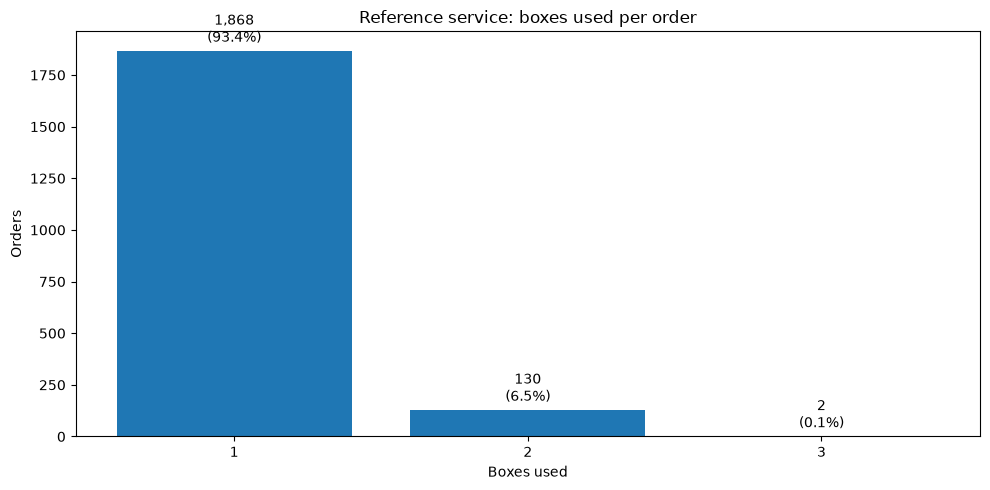

,orders,percent
bins_used,,
1,1868,93.40
2,130,6.50
3,2,0.10


In [7]:
s=orders_df.bins_used.value_counts().sort_index(); pct=s/len(orders_df)*100
fig,ax=plt.subplots(); bars=ax.bar(s.index.astype(str),s.values)
ax.set(title="Reference service: boxes used per order", xlabel="Boxes used", ylabel="Orders")
ax.bar_label(bars, labels=[f'{v:,}\n({p:.1f}%)' for v,p in zip(s.values,pct.values)], padding=3)
plt.tight_layout(); plt.show()
display(pd.DataFrame({"orders":s,"percent":pct.round(2)}))

**Insight.** The reference service packs **1,868 orders (93.4%) into one carton**. Only 130 orders require two cartons and just 2 require three. This strongly supports carton count as the primary benchmark objective: most of the evaluation will distinguish whether our solver can preserve the one-carton outcome when a feasible 3D arrangement exists.

## 6. Which cartons are selected?

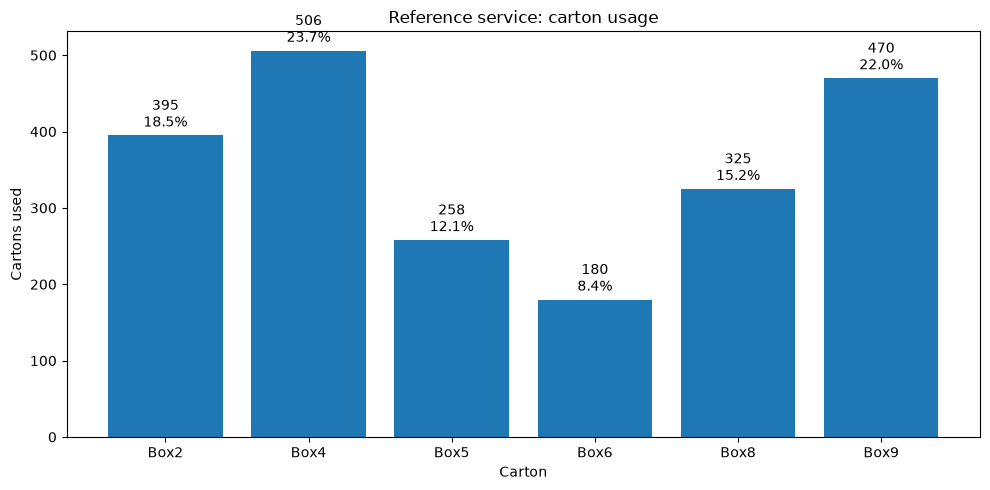

In [8]:
s=packed_df.box.value_counts().sort_index(); pct=s/s.sum()*100
fig,ax=plt.subplots(); bars=ax.bar(s.index,s.values)
ax.set(title="Reference service: carton usage", xlabel="Carton", ylabel="Cartons used")
ax.bar_label(bars, labels=[f'{v:,}\n{p:.1f}%' for v,p in zip(s.values,pct.values)], padding=3)
plt.tight_layout(); plt.show()

**Insight.** `Box4` is the most frequently used carton in v2 with **506 uses**, followed by `Box9` with **470** and `Box2` with **395**. `Box3` has disappeared from the catalogue entirely. The selection mix therefore reflects the updated v2 carton catalogue, not a change in the underlying 2,000 orders.

## 7. Carton utilization

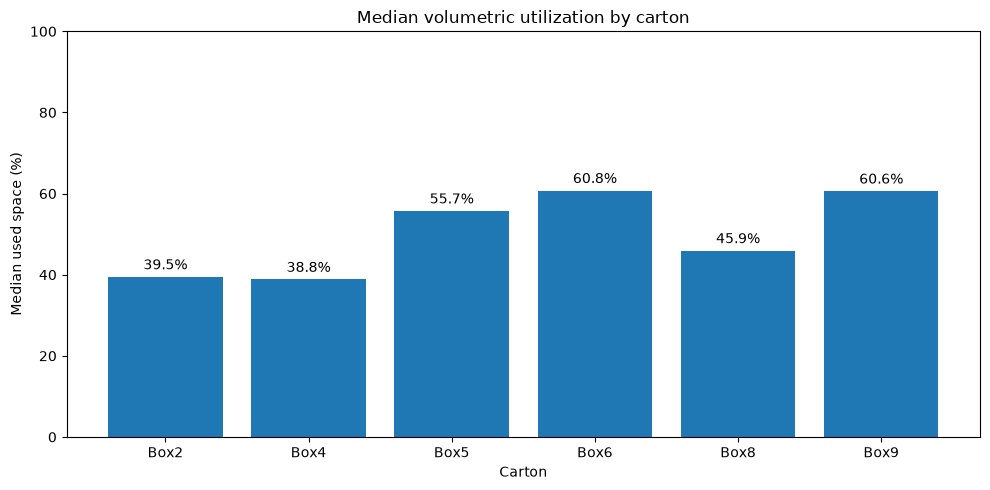

,count,mean,median,min,max
box,,,,,
Box2,395,35.92,39.48,4.16,92.34
Box4,506,40.74,38.84,13.01,74.72
Box5,258,55.01,55.71,24.71,74.17
Box6,180,59.96,60.75,40.35,84.49
Box8,325,45.71,45.92,9.40,85.37
Box9,470,60.35,60.61,15.88,97.11


In [9]:
u=packed_df.groupby("box").used_space.agg(["count","mean","median","min","max"]).round(2)
fig,ax=plt.subplots(); bars=ax.bar(u.index,u["median"])
ax.set(title="Median volumetric utilization by carton", xlabel="Carton", ylabel="Median used space (%)", ylim=(0,100))
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in u["median"]], padding=3)
plt.tight_layout(); plt.show(); display(u)

**Insight.** Median utilization varies substantially by carton. `Box9` and `Box6` are around **61% median fill**, while `Box2` and `Box4` are around **39%**. A low fill percentage is not automatically a poor solution because 3D geometry, rotation restrictions, the 6 mm buffer and the carton-count objective can force a larger carton even when unused volume remains.

### Utilization when the 70% fill cap applies

The 70% maximum fill rule only applies when an order contains more than 6 physical items. This view filters to those orders so the threshold can be checked directly.

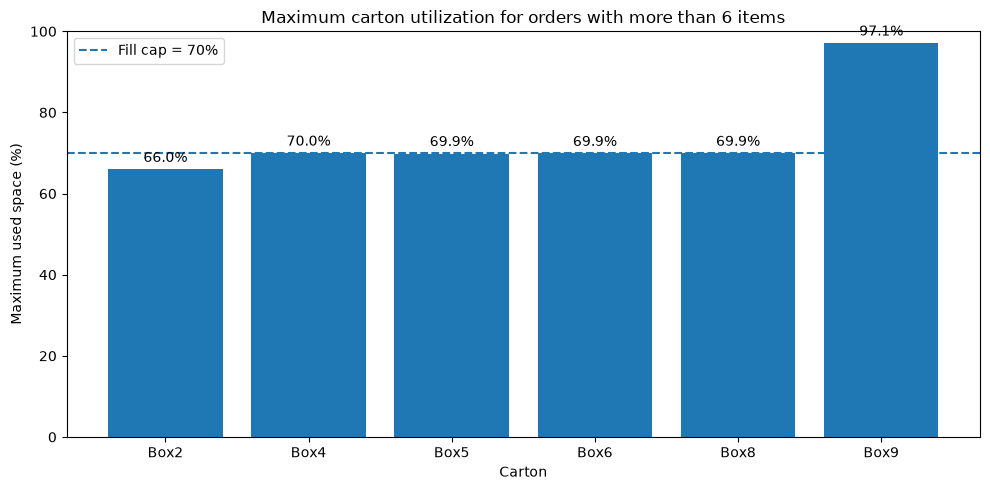

,count,median,max
box,,,
Box2,121,41.57,65.96
Box4,139,41.87,69.98
Box5,159,56.40,69.87
Box6,114,59.49,69.89
Box8,172,50.03,69.93
Box9,386,66.04,97.11


Orders with > 6 items: 973
Packed cartons checked: 1,091
Cartons above 70%: 183


In [10]:
qty_threshold = params["BinMaxFillCheckMinItemQty"]
fill_limit = params["BinMaxFillPct"]
eligible_order_ids = orders_df.loc[orders_df.item_qty > qty_threshold, "order_id"]
gt6_packed = packed_df[packed_df.OrderId.isin(eligible_order_ids)].copy()
gt6_summary = gt6_packed.groupby("box").used_space.agg(["count", "median", "max"]).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(gt6_summary.index, gt6_summary["max"])
ax.axhline(fill_limit, linestyle="--", linewidth=1.5, label=f"Fill cap = {fill_limit}%")
ax.set(title=f"Maximum carton utilization for orders with more than {qty_threshold} items", xlabel="Carton", ylabel="Maximum used space (%)", ylim=(0, 100))
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in gt6_summary["max"]], padding=3)
ax.legend()
plt.tight_layout(); plt.show()
display(gt6_summary)
violations = gt6_packed[gt6_packed.used_space > fill_limit]
print(f"Orders with > {qty_threshold} items: {len(eligible_order_ids):,}")
print(f"Packed cartons checked: {len(gt6_packed):,}")
print(f"Cartons above {fill_limit}%: {len(violations):,}")


**Insight.** There are **973 orders with more than 6 physical items**, producing **1,091 packed cartons** in the reference output. For `Box2`, `Box4`, `Box5`, `Box6`, and `Box8`, the observed maximum utilization stays at or below the configured **70%** threshold. `Box9` is the exception: it reaches **97.1%**, and **183 Box9 uses exceed 70%** within this order-level filtered population. This means the supplied reference outputs do **not** support a claim that the 70% rule is uniformly enforced across every carton. The data suggests that `Box9` may have additional or exception logic in the existing service, but that behavior is not explained by the supplied parameters and should be confirmed with iHub. The unfiltered chart can still legitimately contain values above 70% for orders with 6 items or fewer, where the fill cap is not expected to apply.

## 8. Upright-only rotation constraint

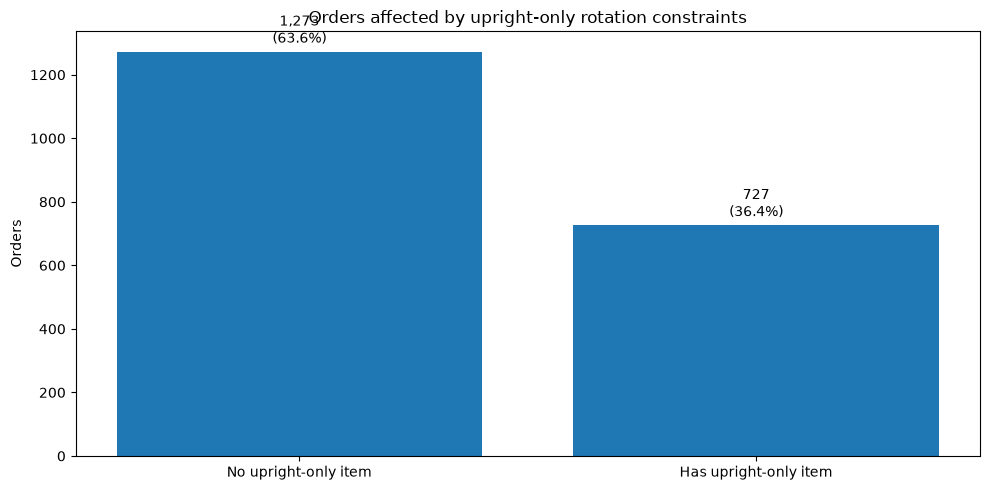

In [11]:
s=pd.Series({"No upright-only item": int((~orders_df.upright_only).sum()), "Has upright-only item": int(orders_df.upright_only.sum())})
fig,ax=plt.subplots(); bars=ax.bar(s.index,s.values)
ax.set(title="Orders affected by upright-only rotation constraints", ylabel="Orders")
ax.bar_label(bars, labels=[f'{v:,}\n({v/len(orders_df)*100:.1f}%)' for v in s.values], padding=3)
plt.tight_layout(); plt.show()

**Insight.** **727 orders (36.4%)** contain at least one item where `VerticalRotation = 0`. A solver that treats all six cuboid orientations as always valid would therefore violate an important real constraint in more than one-third of the benchmark orders.

## 9. Order processing time vs packing complexity

`latency_ms` is recorded once per complete request/response record, so it represents the **total processing time for the full order**, not line-by-line item latency. Because the solver receives the full order, candidate cartons and constraints before solving, the useful benchmark is how end-to-end runtime changes as order complexity increases.


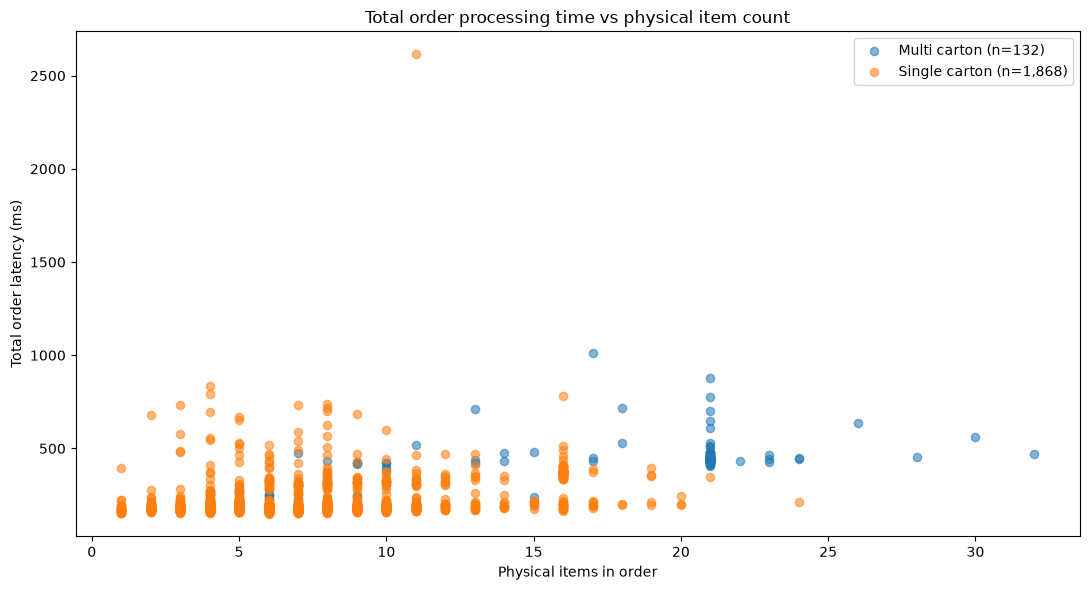

In [12]:
latency_plot = orders_df.copy()
latency_plot['packing_type'] = np.where(latency_plot.bins_used == 1, 'Single carton', 'Multi carton')
fig, ax = plt.subplots(figsize=(11,6))
for label, grp in latency_plot.groupby('packing_type'):
    ax.scatter(grp.item_qty, grp.latency_ms, alpha=0.55, s=35, label=f'{label} (n={len(grp):,})')
ax.set(title='Total order processing time vs physical item count', xlabel='Physical items in order', ylabel='Total order latency (ms)')
ax.legend()
plt.tight_layout(); plt.show()


**Insight.** Each point represents one complete order run. This view lets us compare end-to-end processing time directly against the number of physical items in the order, while separating single-carton and multi-carton outcomes. Multi-carton orders are expected to be more complex, but the chart should be used to verify whether that actually translates into higher observed latency rather than assuming it.


In [13]:
summary = (latency_plot.groupby('packing_type').latency_ms.agg(orders='count', median_ms='median', mean_ms='mean', p95_ms=lambda s: s.quantile(0.95), max_ms='max').round(2))
display(summary)


,orders,median_ms,mean_ms,p95_ms,max_ms
packing_type,,,,,
Multi carton,132,437.70,433.06,640.87,"1,011.15"
Single carton,1868,185.32,211.58,367.93,"2,614.53"


**Benchmark interpretation.** The median and p95 values above are the most useful reference points for our own solver. Later we can compare our full-order runtime at similar order sizes and carton counts against these reference-service timings. This is more meaningful for our batch-style use case than treating latency as an item-level metric.


## 10. Initial takeaways for solver design

1. **Single-carton feasibility is the dominant case.** More than 93% of reference orders use one carton.
2. **The carton catalogue must stay configurable.** v2 itself demonstrates that carton definitions can change while the order population remains the same.
3. **3D geometry still matters.** Volume alone cannot establish feasibility, particularly with upright-only items and buffer constraints.
4. **The 6-item threshold is operationally important.** The median order sits exactly at the threshold where the 70% fill rule starts applying above it.
5. **Order size has a long tail and repeated high-quantity patterns.** The solver should be fast for common 4–10 item orders without becoming fragile on the less common 16–21+ item cases.
6. **Evaluation should separate feasibility, carton count, utilization and runtime.** Matching historical carton choice exactly is useful for benchmarking, but it is not proof that the historical output is the only valid packing.